### Predicting PCOS using Ultrasound images

In [ ]:
#Based in part on Lockhart, BINF761, George Mason University, 2026
#Source: Class lecture notes on CNN architecture design

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

In [ ]:
batch_size = 64
n_epochs = 20

### Load data

In [41]:
data = datasets.ImageFolder(
    root="pcos_dataset",
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Resize((128, 128)),
        transforms.Grayscale(num_output_channels=1),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1)),
        transforms.RandomVerticalFlip(p=0.5),
    ]
),
    
)

#Split into training and testing subsets
train_indices, test_indices = train_test_split(
    range(len(data)),
    test_size = 0.3,
    shuffle=True
)

In [42]:
print("Classes found:", data.classes)
print("Class to index mapping:", data.class_to_idx)

Classes found: ['infected', 'noninfected']
Class to index mapping: {'infected': 0, 'noninfected': 1}


In [43]:
train_data = Subset(data, train_indices)
test_data = Subset(data, test_indices)

In [44]:
#Normalize 
u=torch.zeros(1) #Grayscale, so 1 channel
u2=torch.zeros(1)
n=0
for image, _ in train_data:
    u+=image.mean([1,2])
    u2+= (image**2).mean([1,2])
    n+=1
u/=n
u2/=n
s=(u2-u**2).sqrt()

normalization = transforms.Normalize(u.tolist(), s.tolist())
data.transform.transforms.append(normalization)

## Create DataLoaders

In [45]:
train_loader=DataLoader(
    train_data,
    batch_size = batch_size,
    shuffle=True 
)

test_loader=DataLoader(
    test_data,
    batch_size = batch_size,
    shuffle=True 
)

## Visualize Data

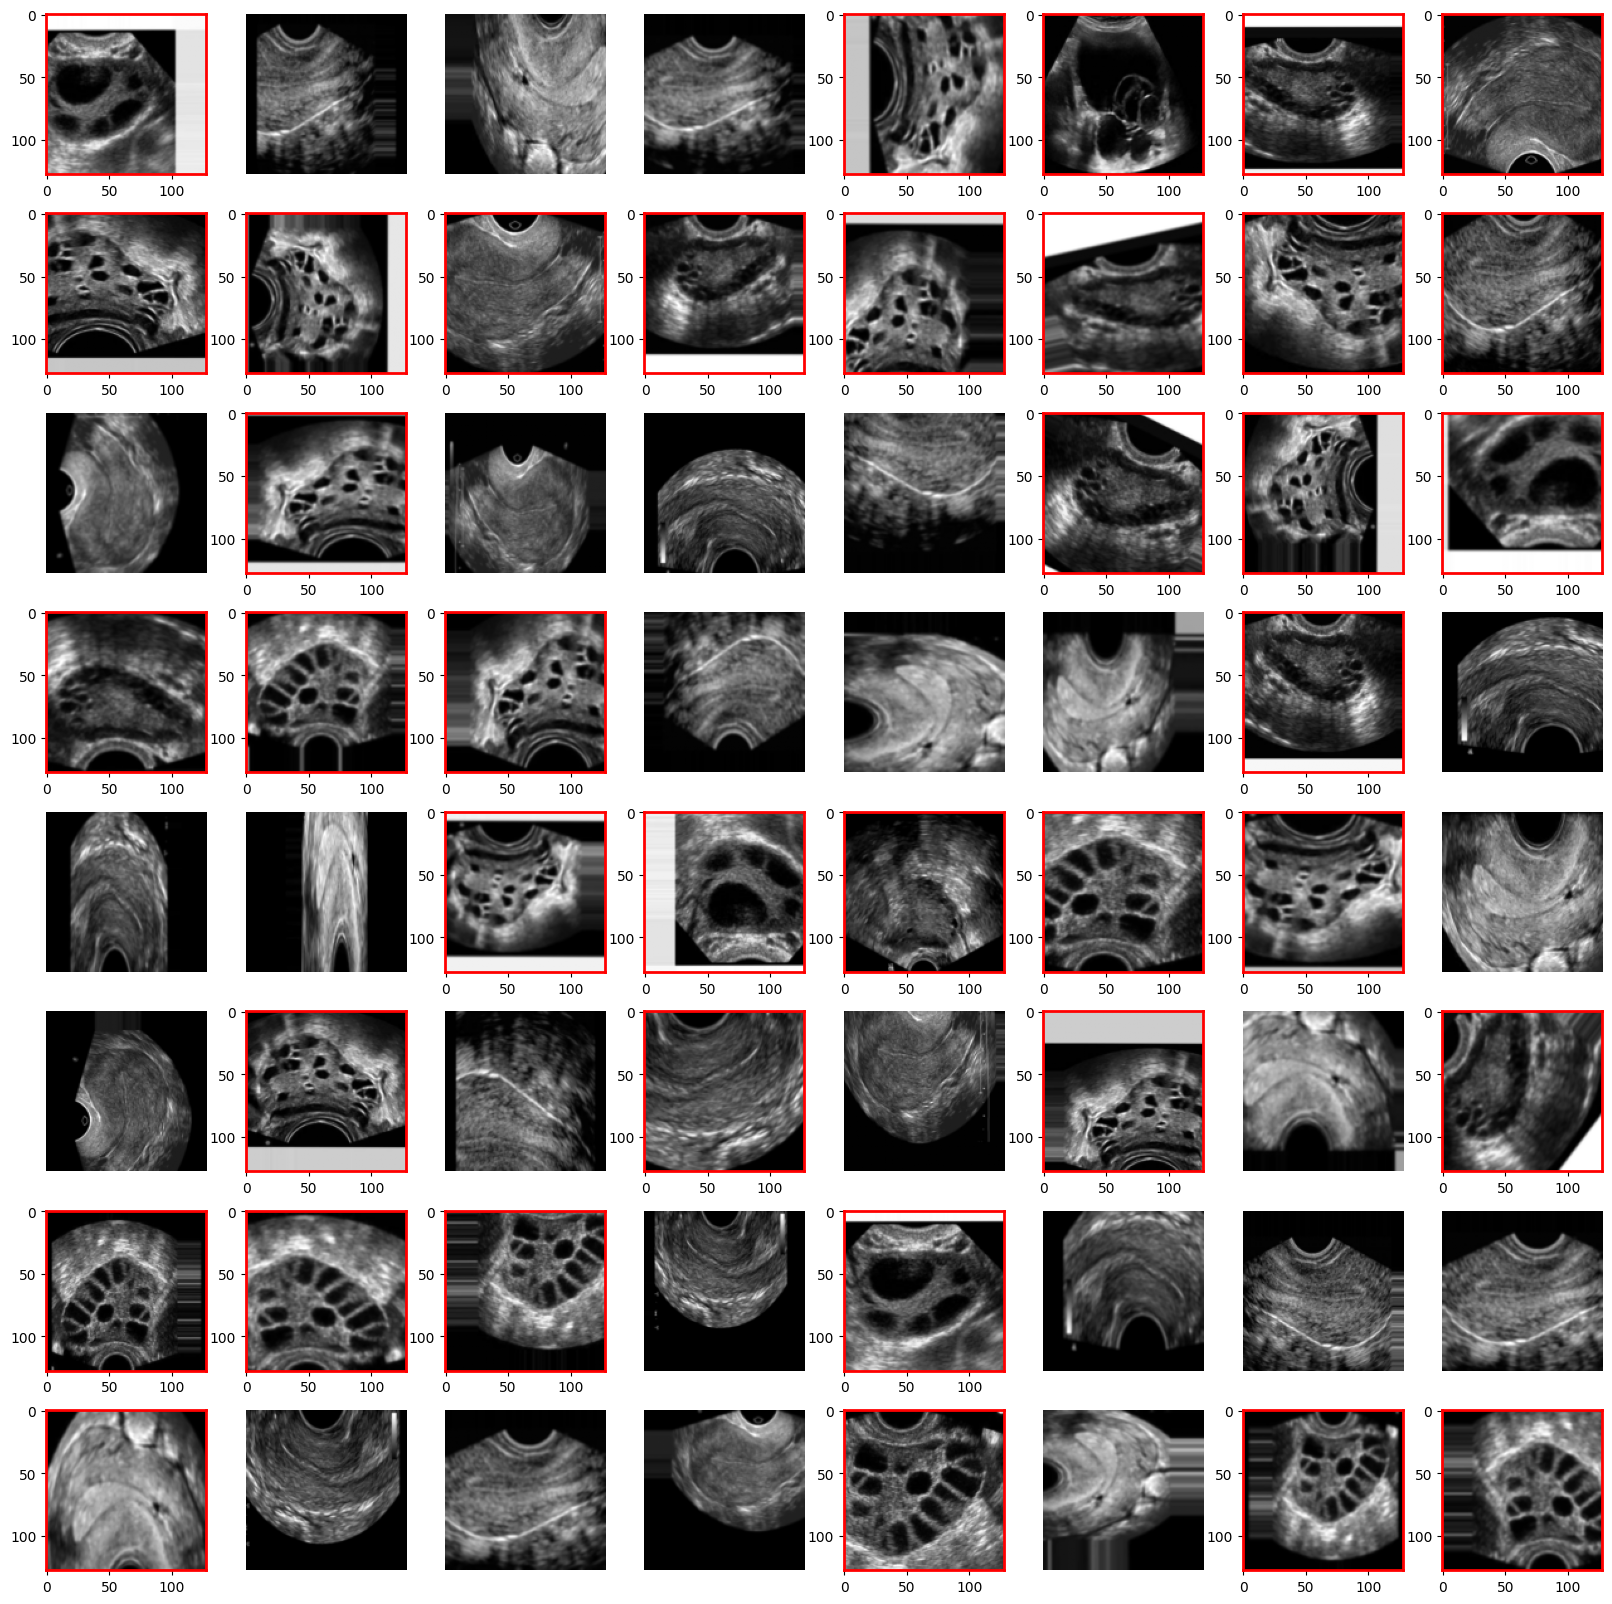

In [46]:
images, labels = next(iter(train_loader)) #Taking one of the batches to visualize
batch_size=images.shape[0] #Number of images in the batch
ncol = int(np.ceil(np.sqrt(batch_size))) #Computing grid size for image display
nrow = int(np.ceil(batch_size/ncol))
fig, ax = plt.subplots(nrow, ncol, figsize=(ncol*2, nrow*2)) #Create figure with nrow and ncol of subplots
# Flatten axes array for easy indexing 
ax = ax.flatten()

# Denormalize and plot for visualization
for k in range(batch_size): 
    # Denormalize
    image = (images[k] * s[:, None, None] + u[:, None, None]).cpu()
    image_np = image.squeeze().numpy()  # remove channel dimension for grayscale

    ax[k].imshow(image_np, cmap="gray")
    ax[k].axis("off")  # hide axes ticks by default

    # Highlight PCOS images with red border; the dataset labels them as infected
    if labels[k] == 0:
        for spine in ax[k].spines.values():
            spine.set_linewidth(2)
            spine.set_edgecolor("red")
        ax[k].axis("on")  # show border


plt.tight_layout(pad=0.3)
plt.show()



In [47]:
#Print the size of the image tensors to confirm for use in the model
print(images.shape)

torch.Size([64, 1, 128, 128])


## Model

In [53]:
model = nn.Sequential(
    #Input: 1 channel, each with 128^2 tensor
    #Output: 32 channels each with (128-3+1)^2=126^2 Kernel Size: 3
    nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3),
    nn.BatchNorm2d(32), #adding batch normalization
    nn.ReLU(), #ReLU activation function
    #Input: 32 channels each with 126 tensor
    #Output: 32 channels each with (126-3+1)^2 = 124^2 tensor
    nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3),
    nn.BatchNorm2d(32), #adding batch normalization
    nn.ReLU(),
    #Dropout
    nn.Dropout(0.25),
    #Input: 32 channels with 124^2 tensor
    #Output: 32 channels with 62^2 tesnor
    nn.MaxPool2d(kernel_size=2),
    #Input: 32 channels with 62^2 tensor
    #Output: 32 channels each with (62-3+1)^2 = 60^2 tensor
    nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3),
    nn.BatchNorm2d(32), #adding batch normalization
    nn.ReLU(),
    #Dropout
    nn.Dropout(0.25), #Adding another dropout to reduce overfitting
    #Input: 32 channels with 60^2 tensor
    #Output: 32 channels with 30^2 tensor
    nn.MaxPool2d(kernel_size=2),
    #Input: 32 channels with 30^2 tensor
    #Output: 16 channels with (30-3+1)^2 = 28^2 tensor
    nn.Conv2d(in_channels=32, out_channels=16, kernel_size=3),
    nn.BatchNorm2d(16), #adding batch normalization
    nn.ReLU(),
    #Dropout
    nn.Dropout(0.25),
    #Input: 16 channels with 28^2 tensor
    #Output: 16 channels with 14^2 tensor
    nn.MaxPool2d(kernel_size=2),
    #Input: 16 channels with 14^2 tensor
    #Output: 16*14*14 = 3136
    nn.Flatten(),
    #Fully connected neural network with 1 hidden layer
    nn.Linear(3136, 64),
    nn.ReLU(),
    nn.Dropout(0.5), #Model was extremely overfit, so using dropout to mitigate that
    nn.Linear(64, 1),
)

In [54]:
model

Sequential(
  (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1))
  (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (5): ReLU()
  (6): Dropout(p=0.25, inplace=False)
  (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (8): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1))
  (9): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (10): ReLU()
  (11): Dropout(p=0.25, inplace=False)
  (12): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (13): Conv2d(32, 16, kernel_size=(3, 3), stride=(1, 1))
  (14): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (15): ReLU()
  (16): Dropout(p=0.25, inplace=False)
  (17): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_m

## Train

In [56]:
for i, layer in enumerate(model):
    print(i, layer)

0 Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
1 BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
2 ReLU()
3 Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1))
4 BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
5 ReLU()
6 Dropout(p=0.25, inplace=False)
7 MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
8 Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1))
9 BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
10 ReLU()
11 Dropout(p=0.25, inplace=False)
12 MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
13 Conv2d(32, 16, kernel_size=(3, 3), stride=(1, 1))
14 BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
15 ReLU()
16 Dropout(p=0.25, inplace=False)
17 MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
18 Flatten(start_dim=1, end_dim=-1)
19 Linear(in_features=3136, out_features=64, bias=True)

In [58]:
#After some testing, found that the model is heavily overfit, so I'm adding noise
noise = 1e-4
model.train()
#Define optimizer and loss function
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4)
#Adding LogitsLoss to account for class imbalance
pos_weight = torch.tensor([5000/6784])
loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

#Training loop
losses = []
for epoch in range(n_epochs):
    for X, y in train_loader:
        optimizer.zero_grad()
        yhat = model(X)
        loss = loss_fn(yhat, y.float().view(-1,1))
        losses.append(loss.item())
        loss.backward()
        optimizer.step()

        with torch.no_grad():
            for m in model:
                if isinstance(m, (nn.Conv2d, nn.Linear)):
                    m.weight.add_(noise*torch.randn_like(m.weight)) #noise
    print(losses[-1])

0.2594878673553467
0.12294819205999374
0.10293576866388321
0.14178858697414398
0.08536489307880402
0.07286310195922852
0.06406629830598831
0.10618969053030014
0.07936488837003708
0.05336238816380501
0.04679640009999275
0.08260679244995117
0.02640702947974205
0.1227530986070633
0.21582333743572235
0.0237104594707489
0.11042334139347076
0.03650737926363945
0.025437653064727783
0.07860035449266434


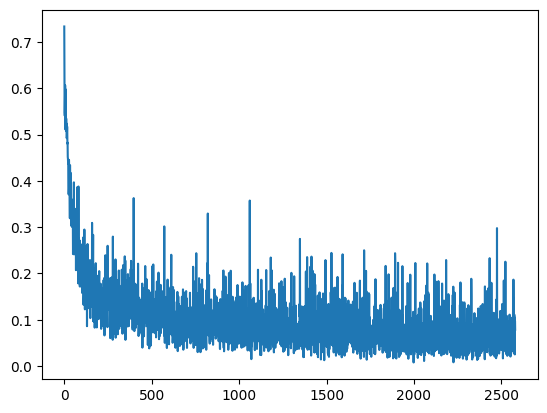

In [59]:
fig, ax = plt.subplots()
ax.plot(losses)

## Evaluate

In [60]:
model.eval()

#Training
ys = []
yhats = []
for X, y in train_loader:
    ys.extend(y.numpy().tolist())
    yhats.extend(torch.sigmoid(model(X)).detach().numpy().tolist())
print("Train")
print("Accuracy = ", accuracy_score(ys, np.array(yhats) > 0.5))
print("Precision = ", precision_score(ys, np.array(yhats) > 0.5))
print("Recall = ", recall_score(ys, np.array(yhats) > 0.5))
print("ROC AUC = ", roc_auc_score(ys, yhats))

#Testing
ys = []
yhats = []
for X, y in test_loader:
    ys.extend(y.numpy().tolist())
    yhats.extend(torch.sigmoid(model(X)).detach().numpy().tolist())
print("Test")
print("Accuracy = ", accuracy_score(ys, np.array(yhats) > 0.5))
print("Precision = ", precision_score(ys, np.array(yhats) > 0.5))
print("Recall = ", recall_score(ys, np.array(yhats) > 0.5))
print("ROC AUC = ", roc_auc_score(ys, yhats))

Train
Accuracy =  0.9677497575169738
Precision =  0.9467471863848477
Recall =  0.9795512638454984
ROC AUC =  0.9963474614851313
Test
Accuracy =  0.9725678733031674
Precision =  0.957010582010582
Recall =  0.9783637592968222
ROC AUC =  0.9954317502234327


In [61]:
data2 = datasets.ImageFolder(
    root="combined_data",
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Resize((128, 128)),
        transforms.Grayscale(num_output_channels=1),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1)),
        transforms.RandomVerticalFlip(p=0.5),
    ]
),
)

train_indices, test_indices = train_test_split(
    range(len(data2)),
    test_size = 0.3,
    shuffle=True
)
test_data_2 = Subset(data2, test_indices)

In [62]:
test_loader_2=DataLoader(
    test_data_2,
    batch_size = batch_size,
    shuffle=True 
)

In [63]:
normalization = transforms.Normalize(u.tolist(), s.tolist())
data2.transform.transforms.append(normalization)

In [64]:
#Testing 2
ys_2 = []
yhats_2 = []
for X, y in test_loader_2:
    ys_2.extend(y.numpy().tolist())
    yhats_2.extend(torch.sigmoid(model(X)).detach().numpy().tolist())
print("Test")
print("Accuracy = ", accuracy_score(ys_2, np.array(yhats_2) > 0.5))
print("Precision = ", precision_score(ys_2, np.array(yhats_2) > 0.5))
print("Recall = ", recall_score(ys_2, np.array(yhats_2) > 0.5))
print("ROC AUC = ", roc_auc_score(ys_2, yhats_2))

Test
Accuracy =  0.9826689774696707
Precision =  1.0
Recall =  0.9708029197080292
ROC AUC =  0.9997074066580548
